<a href="https://colab.research.google.com/github/Coolguy4123/Data-Visualization-Project-2/blob/main/CS4990_ResumeVis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preprocessing

In [2]:
import pandas as pd

df = pd.read_csv("/content/Resume.csv", on_bad_lines='skip')

print(df.columns)
df.head()

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [3]:
# --- Dropping columns "ID" & "Resume_html" ---
df.drop(columns=["ID", "Resume_html"], inplace=True)
df.head()

print("Columns currently in memory:", df.columns)
df.head()

Columns currently in memory: Index(['Resume_str', 'Category'], dtype='object')


,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


# Text Preprocessing

In [4]:
import nltk

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab") # For colab
# nltk.download("punkt") # For local runtime

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re

stop_words = set(stopwords.words("english"))
lemmen = WordNetLemmatizer()
buzzwords = ["company", "name", "city", "state", "experience", "skill", "skills"]  # Resume buzzwords

def text_preprocessing(text: str) -> str:
  text = text.lower()                                                                   # Lower case the text
  text = re.sub(r"[^\w\s]", " ", text)                                                  # Remove punctuation
  text = word_tokenize(text)                                                            # Tokenize
  text = [word for word in text if word not in stop_words]                              # Remove stop words
  text = [word for word in text if word.isalpha() and len(word) > 2]                    # Remove numbers and short words
  text = [lemmen.lemmatize(word) for word in text]                                      # Lemmentize word (running -> run)
  text = [word for word in text if word not in buzzwords]                              # Remove resume buzzwords
  return " ".join(text)


df["Resume_str"] = df["Resume_str"].apply(text_preprocessing)
df.head()


,Resume_str,Category
0,administrator marketing associate administrato...,HR
1,specialist operation summary versatile medium ...,HR
2,director summary year recruiting plus year hum...,HR
3,specialist summary dedicated driven dynamic ye...,HR
4,manager highlight department startup three new...,HR


In [6]:
# df.to_csv("Preprocessed.csv")

# Text Feature Extraction

In [7]:
# Term-Frequency
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(df["Resume_str"])


In [8]:
# Get the list of unique words (features) learned by the vectorizer
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20])

['aa' 'aaa' 'aaae' 'aaahc' 'aaai' 'aac' 'aacc' 'aaccounting' 'aacn'
 'aacsb' 'aade' 'aaditya' 'aadt' 'aafes' 'aafet' 'aagi' 'aaham' 'aai'
 'aakash' 'aalto']


In [9]:
import pandas as pd

# Each column represents a word, each row represents a resume
tf_df = pd.DataFrame(X_counts.toarray(), columns=feature_names)
tf_df.head()

,aa,aaa,aaae,aaahc,aaai,aac,aacc,aaccounting,aacn,aacsb,...,zzxzx,µpg,çatalhöyük,école,ética,étiquette,éxito,òwaterfalló,últimos,ﬁlm
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
import numpy as np

word_counts = X_counts.toarray().sum(axis=0) # Sum word counts across all documents

tf_summary = pd.DataFrame({
    "word": feature_names,
    "frequency": word_counts
}).sort_values(by="frequency", ascending=False)

tf_summary.head(10)

,word,frequency
17792,management,12179
7329,customer,11345
26761,service,9070
26006,sale,8553
4160,business,8089
23441,project,7887
29147,system,7256
29418,team,7117
5574,client,6503
20059,new,6407


In [11]:
doc_idx = 3
doc_counts = tf_df.iloc[doc_idx]

top_words = doc_counts.sort_values(ascending=False).head(10)
print(top_words)

client        7
customer      7
management    6
call          6
team          5
microsoft     5
service       5
inquiry       4
maintained    4
resolution    4
Name: 3, dtype: int64


# Visualization

In [12]:
# Install wordcloud library
!pip install wordcloud

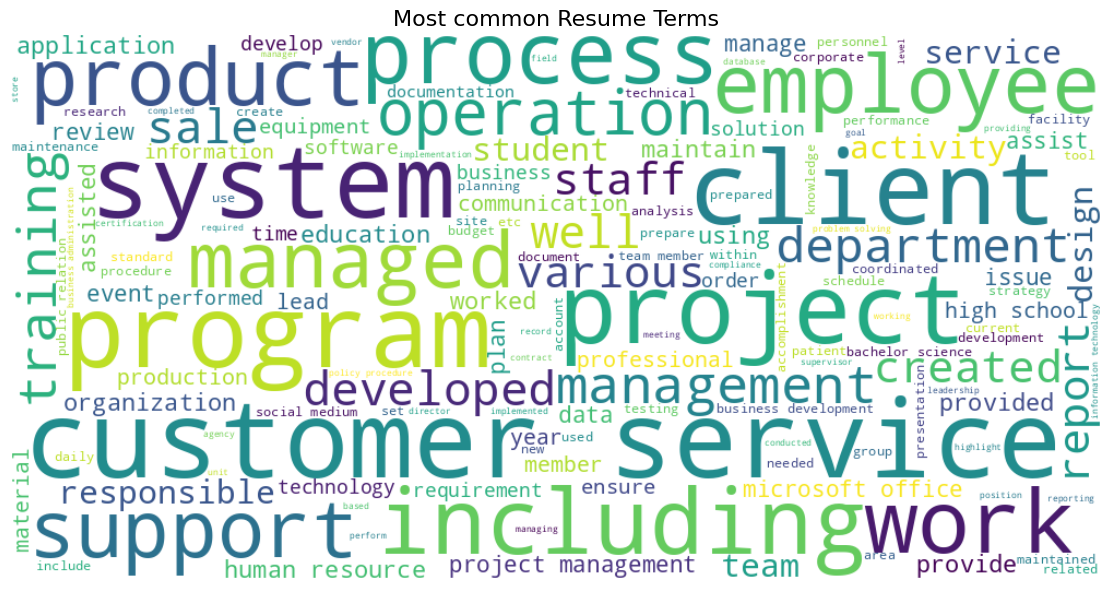

In [13]:
# Word cloud showing the most frequent terms across all resumes

import matplotlib.pyplot as plt
from wordcloud import WordCloud

all_text = " ".join(df["Resume_str"])

wordcloud = WordCloud(width=1000, height=500, background_color="white",
                      max_words=150, colormap="viridis").generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most common Resume Terms", fontsize=16)
plt.tight_layout()
plt.show()

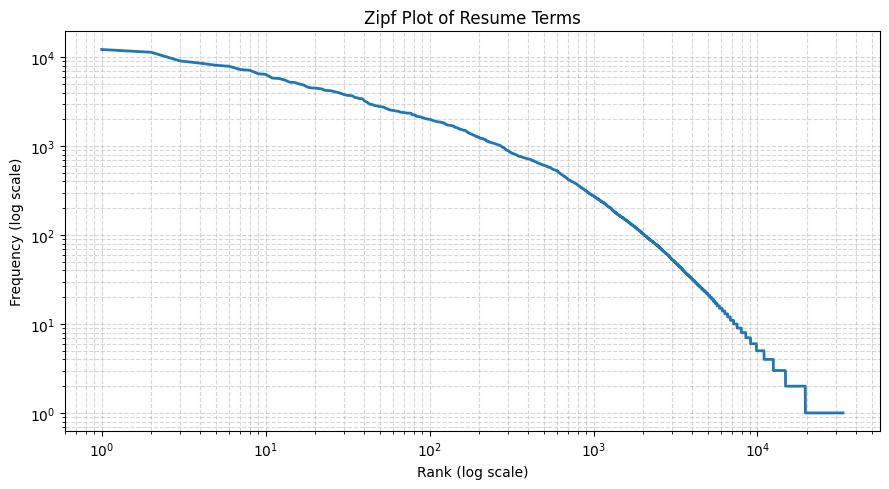

In [14]:
#Zipf plot showing the rank-frequency distribution of resume terms

import numpy as np

freqs = tf_summary["frequency"].values
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(9, 5))
plt.loglog(ranks, freqs, linewidth=2)
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Zipf Plot of Resume Terms")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

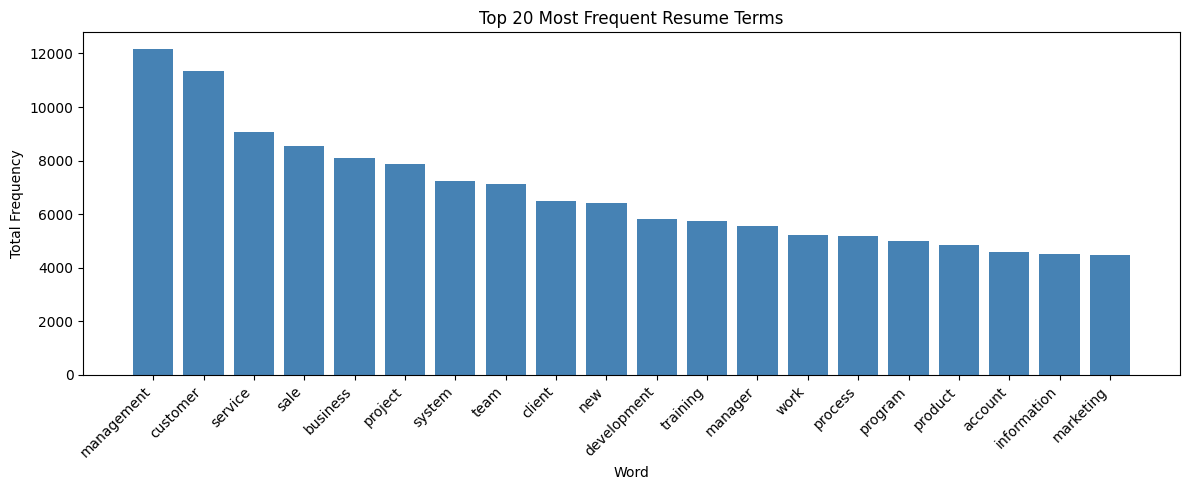

In [15]:
# Bar chart of the top 20 most frequent terms across all resumes

top20 = tf_summary.head(20)

plt.figure(figsize=(12, 5))
plt.bar(top20["word"], top20["frequency"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Word")
plt.ylabel("Total Frequency")
plt.title("Top 20 Most Frequent Resume Terms")
plt.tight_layout()
plt.show()

In [16]:
# Interactive word cloud by category

import ipywidgets as widgets
from wordcloud import WordCloud
import matplotlib.pyplot as plt

category_options = ["All"] + sorted(df["Category"].unique().tolist())

dropdown = widgets.Dropdown(options=category_options, description="Category:")

def update_wordcloud(category):
  if category == "All":
    filtered_text = " ".join(df["Resume_str"])
  else:
    filtered_text = " ".join(df.loc[df["Category"] == category, "Resume_str"])

  wc = WordCloud(width=1000, height=500, background_color="white",
              max_words=150, colormap="viridis").generate(filtered_text)

  plt.figure(figsize=(14, 6))
  plt.imshow(wc, interpolation="bilinear")
  plt.axis("off")
  plt.title(f"Most Common Terms - {category}", fontsize=16)
  plt.tight_layout()
  plt.show()

widgets.interactive(update_wordcloud, category=dropdown)

interactive(children=(Dropdown(description='Category:', options=('All', 'ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE…

# Interactive Development

In [17]:
# TF-IDF and Similarity Calculation
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Initialize and fit TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Resume_str'])

# 2. Search Function: Finds top N resumes matching a query string
def search_resumes(query):
    query = query.lower()
    # Search in the Resume_str column
    results = df[df['Resume_str'].str.contains(query, case=False, na=False)]

    # Return specific columns only if they exist
    cols_to_show = [c for c in ['ID', 'Category', 'Resume_str'] if c in df.columns]
    return results[cols_to_show].head(10)

# Example usage that won't crash:
# search_resumes("advocate")

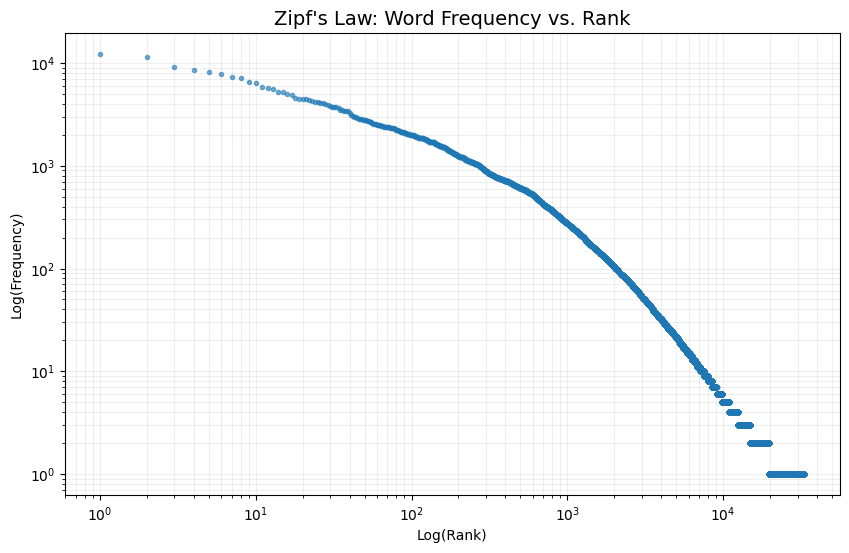

In [18]:
# Zipf's Law Plot

import matplotlib.pyplot as plt
import numpy as np

def plot_zipf_law(tf_df):
    # Sort frequencies and assign ranks
    sorted_counts = tf_df.sort_values(by='frequency', ascending=False)
    sorted_counts['rank'] = range(1, len(sorted_counts) + 1)

    plt.figure(figsize=(10, 6))
    plt.loglog(sorted_counts['rank'], sorted_counts['frequency'], marker=".", linestyle="none", alpha=0.6)

    plt.title("Zipf's Law: Word Frequency vs. Rank", fontsize=14)
    plt.xlabel("Log(Rank)")
    plt.ylabel("Log(Frequency)")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

# Run the plot using the tf_summary table created by your teammates
plot_zipf_law(tf_summary)

In [20]:
# Interactive
import ipywidgets as widgets
from IPython.display import display, clear_output
import seaborn as sns

# UI Elements
category_filter = widgets.Dropdown(
    options=['All Categories'] + sorted(df['Category'].unique().tolist()),
    value='All Categories',
    description='Filter By:',
)

search_input = widgets.Text(
    placeholder='Type keywords (e.g. "Python", "Manager")...',
    description='Search:',
)

output_area = widgets.Output()

def update_dashboard(change):
    with output_area:
        clear_output(wait=True)

        # 1. Filter Data based on dropdown
        if category_filter.value == 'All Categories':
            filtered_df = df
        else:
            filtered_df = df[df['Category'] == category_filter.value]

        # 2. Create Layout
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

        # Left Side: Category-Specific Word Cloud
        all_text = " ".join(filtered_df['Resume_str'])
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
        ax1.imshow(wordcloud, interpolation='bilinear')
        ax1.set_title(f"Top Keywords: {category_filter.value}")
        ax1.axis('off')

        # Right Side: Top 10 Words Bar Chart
        top_words = pd.Series(word_tokenize(all_text)).value_counts().head(10)
        sns.barplot(x=top_words.values, y=top_words.index, ax=ax2, palette='magma')
        ax2.set_title("Word Frequency Distribution")

        plt.tight_layout()
        plt.show()

        # 3. Search Results Section
        if search_input.value:
            print(f"\n--- Search Results for: '{search_input.value}' ---")
            results = search_resumes(search_input.value)
            display(results)

# Link the widgets to the update function
category_filter.observe(update_dashboard, names='value')
search_input.observe(update_dashboard, names='value')

# Display the Dashboard
print("--- PROJECT 2: RESUME EXPLORER DASHBOARD ---")
display(widgets.VBox([widgets.HBox([category_filter, search_input]), output_area]))

# Initial Run
update_dashboard(None)

--- PROJECT 2: RESUME EXPLORER DASHBOARD ---
